In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    log_loss,
    brier_score_loss,
)

import seaborn as sns

# Load the dataset
df = pd.read_csv("../data/atp_matches_2000_2019_clean.csv")

# Features
X = [
    "rank_diff",
    "rank_points_diff",
    "age_diff",
    "height_diff",
    "different_hand",
    "elo_diff",
    "elo_diff_surface",
    "serve_advantage_diff",
    "complete_diff",
    "form_diff",
]

# Target
y = "result"

# Empty storage lists
dates = []
predictions = []
actuals = []
probabilities = []
best_params_list = []
cv_monitor = []

# Rolling setup
WINDOW_SIZE = 4000   # esim. ~1.5 vuotta dataa
STEP = 25

LOGIT = LogisticRegression(
    max_iter=5000,
    random_state=1
)

pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LOGIT),
])

# Hyperparameter C grid
param_grid = {
    "clf__C": [0.05, 0.1, 0.2, 0.3, 1, 5, 10]
}

# Rolling window forecast loop
for i in range(WINDOW_SIZE, len(df), STEP):
    train_data = df.iloc[i-WINDOW_SIZE:i]
    test_data = df.iloc[i:i+STEP]

    if len(test_data) == 0:
        break

    X_train = train_data[X]
    y_train = train_data[y]
    X_test = test_data[X]
    y_test = test_data[y]

    tscv = TimeSeriesSplit(n_splits=2)

    search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=tscv,
        n_jobs=-1,
        scoring="neg_log_loss",
        refit=True,
        return_train_score=True
    )

    search.fit(X_train, y_train)

    # CV monitoring
    res = pd.DataFrame(search.cv_results_)
    best_row = res.iloc[search.best_index_]

    cv_monitor.append({
        "Index": i,
        "Date": test_data["tourney_date"].iloc[0],
        "Best_Params": search.best_params_,
        "Mean_Train_Score": float(best_row["mean_train_score"]),
        "Mean_Valid_Score": float(best_row["mean_test_score"]),
    })

    # Store predictions
    best_params_list.append(search.best_params_)
    dates.extend(test_data["tourney_date"].tolist())

    preds = search.predict(X_test)
    probs = search.predict_proba(X_test)[:, 1]

    predictions.extend(preds)
    probabilities.extend(probs)
    actuals.extend(y_test.tolist())

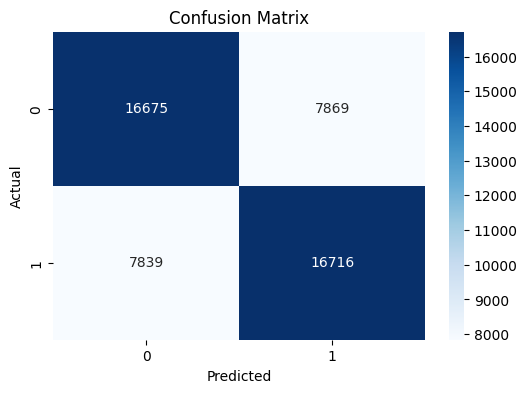

Balanced Accuracy: 0.680
ROC AUC: 0.747
Log Loss: 0.592
Brier Score: 0.204


In [3]:
#Confusion matrix
cm = confusion_matrix(actuals, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Accuracy
accuracy = balanced_accuracy_score(actuals, predictions)
print(f"Balanced Accuracy: {accuracy:.3f}")
#and ROC AUC
roc_auc = roc_auc_score(actuals, probabilities)
print(f"ROC AUC: {roc_auc:.3f}")

#Log loss
logloss = log_loss(actuals, probabilities)
print(f"Log Loss: {logloss:.3f}")

#Brier score
brier_score = brier_score_loss(actuals, probabilities)
print(f"Brier Score: {brier_score:.3f}")
